# 随机森林

https://www.runoob.com/ml/ml-random-forest.html

想象一下，你正在参加一个重要的知识竞赛，面对一个难题，你是更相信一位顶尖专家的判断，还是更相信由 100 位水平不错的选手投票得出的结果？在大多数情况下，集体的智慧往往能弥补个人的偏见和局限，从而做出更稳定、更准确的决策。

在机器学习的世界里，随机森林（Random Forest） 正是这种集体智慧思想的杰出代表。它通过构建大量的决策树，并让它们共同投票来做出预测，从而成为最强大、最受欢迎的机器学习算法之一。

## 简介

### 什么是随机森林？

随机森林 是一种基于集成学习（Ensemble Learning）的机器学习算法。它的核心思想非常简单：三个臭皮匠，顶个诸葛亮。

- 森林： 指的是由多棵 决策树（Decision Tree） 组成的集合。
- 随机： 指的是在构建每一棵决策树时，算法会引入两种随机性，确保每棵树都与众不同。

最终，对于分类任务，森林通过 投票（多数决） 给出结果；对于回归任务，则通过 取平均值 给出结果。

### 核心思想：Bagging 与随机性

随机森林的成功建立在两大基石之上：Bagging（Bootstrap Aggregating）：

- Bootstrap（自助采样）： 从原始训练数据集中有放回地随机抽取样本，生成多个不同的子训练集。这意味着同一个样本可能在一个子集中出现多次，而另一个样本可能一次都不出现。
- Aggregating（聚合）： 用每个子训练集独立训练一棵决策树，最后将所有树的结果聚合起来（投票或平均）。

![](./pic/random_forest.png)

特征随机性：

- 在构建每棵树的每个节点进行分裂时，算法不会考虑所有的特征，而是从全部特征中随机选取一个子集，然后从这个子集中选择最优分裂特征。
- 这进一步增强了树与树之间的差异性，让森林看到问题的不同侧面。

简单来说，随机森林通过让每棵树在略有不同的数据和特征视角下进行训练，创造了一个多样化的专家委员会。 即使其中一些树犯了错误，其他正确的树也能通过投票将其纠正，从而获得比单棵决策树更稳定、更强大的性能。

### 算法流程与关键参数

![](./pic/random_forest_train.png)



## 实战演练 

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [4]:
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [5]:
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
y_pred = rf_clf.predict(X_test)

# 6. 评估模型性能
print("测试集准确率：", accuracy_score(y_test, y_pred))
print("\n分类报告：")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

测试集准确率： 1.0

分类报告：
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



查看特征重要性

测试集准确率： 1.0

分类报告：
特征重要性排序：
                  特征       重要性
3   petal width (cm)  0.436574
2  petal length (cm)  0.417326
0  sepal length (cm)  0.104614
1   sepal width (cm)  0.041486


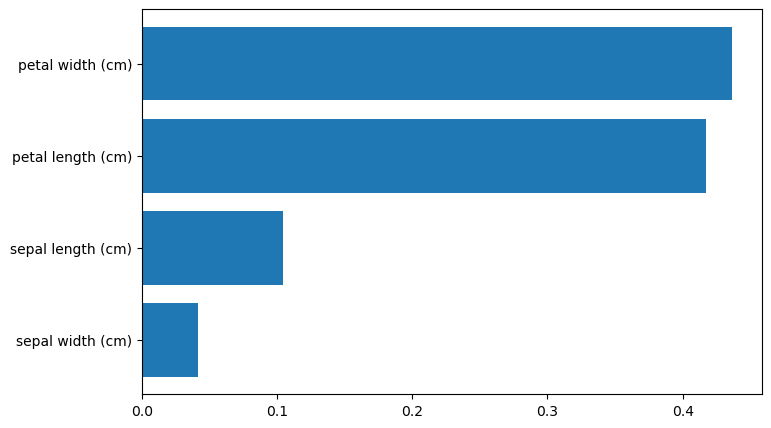

In [8]:
# 导入必要的库
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import pandas as pd
import matplotlib.pyplot as plt

# -------------------------- 设置中文字体 start --------------------------
plt.rcParams['font.sans-serif'] = [
    # Windows 优先
    'SimHei', 'Microsoft YaHei',
    # macOS 优先
    'PingFang SC', 'Heiti TC',
    # Linux 优先
    'WenQuanYi Micro Hei', 'DejaVu Sans'
]
# 修复负号显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False
# -------------------------- 设置中文字体 end --------------------------

# 1. 加载数据
iris = load_iris()
X = iris.data  # 特征：花萼长度、宽度，花瓣长度、宽度
y = iris.target # 标签：三种鸢尾花

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. 创建随机森林分类器
# 这里我们设置 100 棵树，并限制最大深度为 5
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# 4. 训练模型
rf_clf.fit(X_train, y_train)

# 5. 在测试集上进行预测
y_pred = rf_clf.predict(X_test)

# 6. 评估模型性能
print("测试集准确率：", accuracy_score(y_test, y_pred))
print("\n分类报告：")


# 获取特征重要性
feature_importances = rf_clf.feature_importances_
features = iris.feature_names

# 创建 DataFrame 便于查看
importance_df = pd.DataFrame({
    '特征': features,
    '重要性': feature_importances
}).sort_values('重要性', ascending=False)

print("特征重要性排序：")
print(importance_df)

# 可视化
plt.figure(figsize=(8, 5))
plt.barh(importance_df['特征'], importance_df['重要性'])
plt.gca().invert_yaxis() # 让最重要的特征显示在顶部
plt.show()